# Notebook 4 — Baseline Models and Evaluation

## Environment Setup for Baseline Modelling

This section prepares the environment required for baseline model development and evaluation. Libraries for data handling, feature extraction, modelling, and evaluation are initialised.

Key machine learning models and metrics are imported to support experimentation and performance assessment. Configuration parameters are accessed to maintain consistency across the pipeline.

An output directory is also prepared to store model artefacts and evaluation results, ensuring organised and reproducible experimentation.

In [1]:
# System path configured for project-level imports
import sys, os, pickle, time
sys.path.insert(0, os.path.abspath('..'))


# Core libraries for data handling
import pandas as pd
import numpy as np


# Visualisation utilities
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


# Sparse matrix operations for feature combination
from scipy.sparse import hstack, csr_matrix


# Text feature extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer


# Baseline models for comparison
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV


# Evaluation metrics for model performance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)


# Warnings suppressed for cleaner output
import warnings
warnings.filterwarnings('ignore')


# Configuration parameters and paths
from config import (
    LABELLED_DATASET,
    VISUALISATION_DIR,
    RANDOM_STATE,
    BEST_BASELINE_PKL,
    BASELINE_RESULTS_CSV,
    NEGATION_CUES,
    INTENSIFIERS
)


# Output directory for baseline model artefacts
BASELINE_DIR = VISUALISATION_DIR / 'baseline_model'
os.makedirs(BASELINE_DIR, exist_ok=True)


# Global plotting configuration for consistency
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': ':',
})

## Data Loading and Splitting

The processed dataset is loaded and partitioned into training, validation, and test sets using the predefined `split` column. This ensures a consistent evaluation pipeline across all models.

Labels are extracted separately for each subset to be used during model training and evaluation. The sizes of each split are printed to verify correct data distribution.

In [2]:
# Load dataset
df = pd.read_csv(LABELLED_DATASET)

# Split dataset
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()
test  = df[df['split'] == 'test'].copy()

# Extract labels
y_train = train['label_id'].values
y_val = val['label_id'].values
y_test = test['label_id'].values

# Print dataset sizes
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 13,467  Val: 3,517  Test: 2,998


## Feature Representation and Augmentation

This section constructs the input feature space for baseline models. Text data is first transformed into TF-IDF vectors using both unigrams and bigrams to capture lexical and contextual information.

Linguistic features are then incorporated to enrich the representation. If required, these features are recomputed to ensure consistency across all dataset splits.

Finally, the sparse TF-IDF matrix is combined with the additional linguistic features to form an augmented feature space, providing both statistical and semantic signals for modelling.

In [3]:
# TF-IDF representation constructed from cleaned text
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(train['text_clean'])
X_val_tfidf = tfidf.transform(val['text_clean'])
X_test_tfidf = tfidf.transform(test['text_clean'])

print(f'TF-IDF matrix: {X_train_tfidf.shape}')

# Linguistic features ensured to exist across splits
def ensure_ling_features(df_split):
    df_split = df_split.copy()

    def count_cues(text, cues):
        return sum(t in cues for t in str(text).lower().split())

    if 'neg_ratio' not in df_split.columns:
        print('  Recomputing neg_ratio (missing from CSV)...')
        
        df_split['negation_count'] = df_split['text_clean'].apply(
            lambda x: count_cues(x, NEGATION_CUES)
        )

        df_split['intensifier_count'] = df_split['text_clean'].apply(
            lambda x: count_cues(x, INTENSIFIERS)
        )

        wc = df_split['text_clean'].str.split().str.len().clip(lower=1)
        df_split['neg_ratio'] = df_split['negation_count'] / wc
        df_split['intens_ratio'] = df_split['intensifier_count'] / wc

    return df_split

# Feature consistency ensured across datasets
train = ensure_ling_features(train)
val   = ensure_ling_features(val)
test  = ensure_ling_features(test)

# Linguistic feature columns selected
ling_cols = [
    c for c in ['intensifier_score', 'neg_ratio', 'intens_ratio']
    if c in train.columns
]
print(f'Linguistic feature columns: {ling_cols}')

# Sparse matrix constructed from linguistic features
def ling_matrix(split):
    return csr_matrix(
        split[ling_cols].fillna(0).values
    )

# Augmented feature space combining TF-IDF and linguistic features
X_train_aug = hstack([
    X_train_tfidf,
    ling_matrix(train)
])

X_val_aug = hstack([
    X_val_tfidf,
    ling_matrix(val)
])

X_test_aug = hstack([
    X_test_tfidf,
    ling_matrix(test)
])

print(f'Augmented matrix: {X_train_aug.shape}')

TF-IDF matrix: (13467, 30000)
Linguistic feature columns: ['intensifier_score', 'neg_ratio', 'intens_ratio']
Augmented matrix: (13467, 30003)


## Model Evaluation Framework

This section defines a unified evaluation function to assess model performance across different splits. Standard classification metrics are computed to provide a comprehensive view of model behaviour.

In addition to numerical metrics, a classification report is displayed to summarise precision, recall, and F1 scores for each class. Where applicable, ROC-AUC is also included.

A confusion matrix is generated to visualise prediction outcomes, allowing easier interpretation of misclassification patterns.

In [4]:
# Evaluation routine for classification models
def evaluate_model(
        model,
        X,
        y_true,
        model_name: str = 'Model',
        split: str = 'val',
        plot: bool = True,
    ) -> dict:
    # Predictions generated from model
    y_pred = model.predict(X)

    # ROC-AUC computed when probability estimates are available
    roc = (
        roc_auc_score(y_true, model.predict_proba(X)[:, 1])
        if hasattr(model, 'predict_proba')
        else float('nan')
    )

    # Core evaluation metrics collected
    metrics = {
        'model': model_name,
        'split': split,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'roc_auc': roc
    }

    # Classification report displayed
    print(f'\n── {model_name} ({split}) ──')
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=['non-suicide', 'suicide']
        )
    )

    # Confusion matrix visualisation
    if plot:
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix(y_true, y_pred),
            display_labels=['non-suicide', 'suicide']
        ).plot(
            ax=ax,
            colorbar=False,
            cmap='Blues'
        )
        ax.set_title(f'{model_name} ({split})', fontweight='bold')
        plt.tight_layout()

        # Safe filename constructed for saving
        safe = model_name.lower().replace(' ', '_')
        plt.savefig(
            BASELINE_DIR / f'cm_{safe}_{split}.png',
            bbox_inches='tight'
        )
        plt.show()
        
    return metrics

## Logistic Regression Baseline

This section trains a Logistic Regression model as a baseline for comparison. The model is configured to handle high-dimensional sparse features efficiently.

Training is performed using the TF-IDF representation of the text. The validation set is then used to assess performance and provide an initial benchmark.

The resulting metrics establish a reference point for evaluating more complex models.


── Logistic Regression (val) ──
              precision    recall  f1-score   support

 non-suicide       0.90      0.93      0.92      1757
     suicide       0.93      0.90      0.92      1760

    accuracy                           0.92      3517
   macro avg       0.92      0.92      0.92      3517
weighted avg       0.92      0.92      0.92      3517



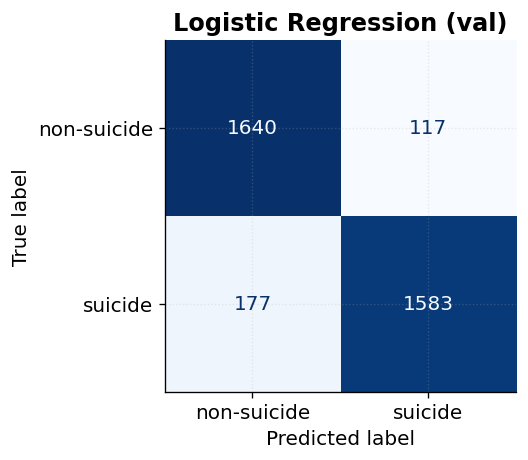

In [5]:
# Logistic Regression Model 
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='saga',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# Model trained on TF-IDF features
lr.fit(
    X_train_tfidf,
    y_train
)

# Validation performance evaluated
lr_val = evaluate_model(
    lr,
    X_val_tfidf,
    y_val,
    'Logistic Regression',
    'val'
)

## Linear SVM Baseline

This section trains a Linear Support Vector Machine as an additional baseline model. The model is suited for high-dimensional text data and is commonly used for classification tasks involving sparse features.

To enable probability-based evaluation metrics, the classifier is calibrated using cross-validation. This allows computation of metrics such as ROC-AUC.

The model is trained on TF-IDF features and evaluated on the validation set to compare its performance against other baselines.


── Linear SVM (val) ──
              precision    recall  f1-score   support

 non-suicide       0.92      0.93      0.93      1757
     suicide       0.93      0.92      0.93      1760

    accuracy                           0.93      3517
   macro avg       0.93      0.93      0.93      3517
weighted avg       0.93      0.93      0.93      3517



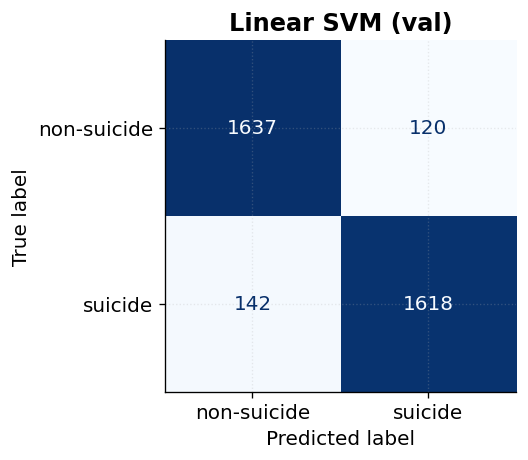

In [6]:
# Linear SVM 
svm = CalibratedClassifierCV(
    LinearSVC(
        C=0.5,
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    cv=3
)

# Model trained on TF-IDF features
svm.fit(
    X_train_tfidf,
    y_train
)

# Validation performance evaluated
svm_val = evaluate_model(
    svm,
    X_val_tfidf,
    y_val,
    'Linear SVM',
    'val'
)

## Random Forest Baseline

This section trains a Random Forest classifier using the augmented feature set. The model leverages both TF-IDF features and additional linguistic signals to capture a richer representation of the data.

Class weighting is applied to account for any imbalance, ensuring that both classes are treated proportionally during training.

The model is evaluated on the validation set to assess how well the combined feature space improves performance compared to text-only baselines.


── Random Forest (val) ──
              precision    recall  f1-score   support

 non-suicide       0.87      0.89      0.88      1757
     suicide       0.89      0.87      0.88      1760

    accuracy                           0.88      3517
   macro avg       0.88      0.88      0.88      3517
weighted avg       0.88      0.88      0.88      3517



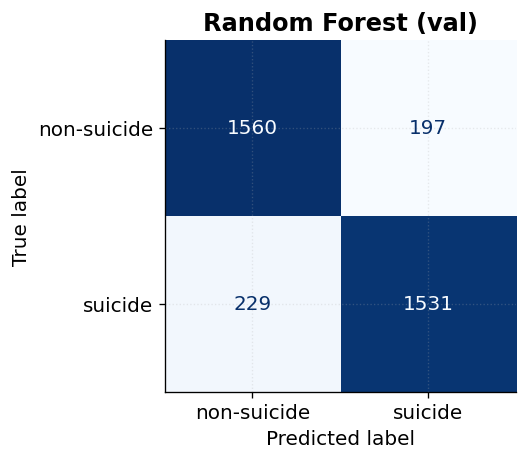

In [7]:
# Random Forest Model
rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

# Model Training
rf.fit(
    X_train_aug,
    y_train
)

# Validation Performance Validation
rf_val = evaluate_model(
    rf,
    X_val_aug,
    y_val,
    'Random Forest',
    'val'
)

## Baseline Model Comparison

This section consolidates validation performance across all baseline models. Key evaluation metrics are presented to enable direct comparison of model effectiveness.

The results are displayed in tabular form and complemented by a grouped bar chart. This visual comparison highlights differences in performance across metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

The analysis provides a clear overview of which model performs best and serves as a reference for subsequent model improvements.

              model  accuracy  precision  recall     f1  roc_auc
Logistic Regression    0.9164     0.9312  0.8994 0.9150   0.9723
         Linear SVM    0.9255     0.9310  0.9193 0.9251   0.9762
      Random Forest    0.8789     0.8860  0.8699 0.8779   0.9429


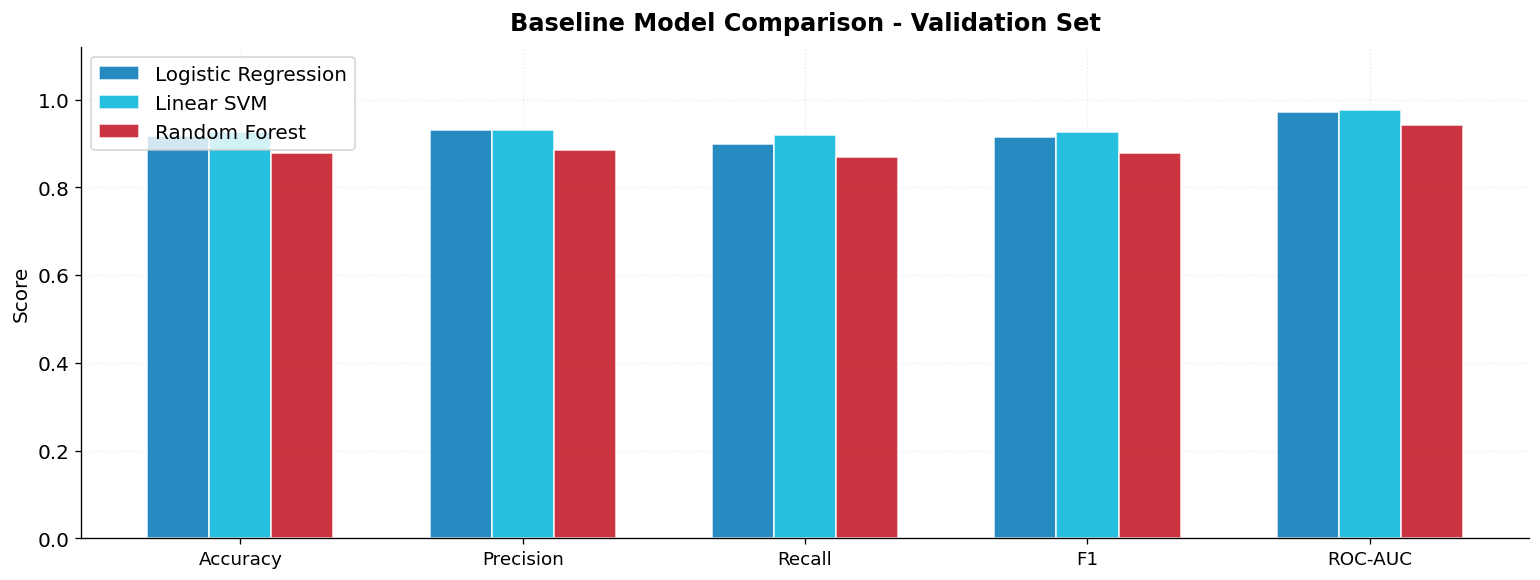

In [8]:
# Results aggregated into a single DataFrame
results_df = pd.DataFrame([lr_val, svm_val, rf_val])

# Key metrics displayed for comparison
print(
    results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
    .round(4)
    .to_string(index=False)
)

# Metrics selected for visual comparison
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x, w = np.arange(len(metrics_to_plot)), 0.22
model_colors = ['#0077B6', '#00B4D8', '#C1121F']

# Grouped bar chart for model performance
fig, ax = plt.subplots(figsize=(13, 5))
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.bar(
        x + (i - 1) * w,
        [row[m] for m in metrics_to_plot],
        w,
        label=row['model'],
        color=model_colors[i],
        alpha=0.85,
        edgecolor='white'
    )

# Axis formatting and labels
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title(
    'Baseline Model Comparison - Validation Set',
    fontweight='bold',
    pad=10
)
ax.legend()
ax.set_axisbelow(True)

# Layout adjustment and figure saved
plt.tight_layout()
plt.savefig(
    BASELINE_DIR / 'baseline_comparison.png',
    bbox_inches='tight'
)
plt.show()

## Best Model Selection and Test Evaluation

This section identifies the best-performing baseline model based on validation F1-score. The selected model is then evaluated on the test set to obtain an unbiased estimate of performance.

The evaluation follows the same framework used previously, ensuring consistency in metric computation and interpretation.

Finally, the best model and associated artefacts are saved for future use, along with the complete set of baseline results.

Best baseline by F1: Linear SVM

── Linear SVM (Best) (test) ──
              precision    recall  f1-score   support

 non-suicide       0.92      0.94      0.93      1498
     suicide       0.93      0.92      0.93      1500

    accuracy                           0.93      2998
   macro avg       0.93      0.93      0.93      2998
weighted avg       0.93      0.93      0.93      2998



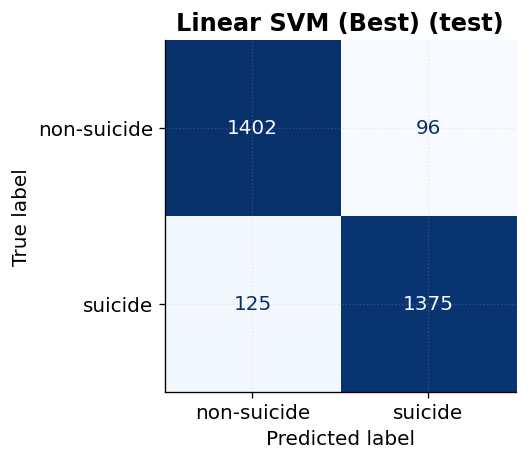

In [ ]:
# Select best model based on validation F1-score
best_name = results_df.loc[results_df['f1'].idxmax(), 'model']

best_model_map = {
    'Logistic Regression': (lr,  X_test_tfidf),
    'Linear SVM':          (svm, X_test_tfidf),
    'Random Forest':       (rf,  X_test_aug),
}

best_model, X_test_best = best_model_map[best_name]

print(f'Best baseline by F1: {best_name}')


# Evaluate on test set
test_metrics = evaluate_model(
    best_model,
    X_test_best,
    y_test,
    best_name + ' (Best)', 'test'
)

# Append test result to results table
final_results_df = pd.concat(
    [results_df, pd.DataFrame([test_metrics])],
    ignore_index=True
)

# Save best model
with open(BEST_BASELINE_PKL, 'wb') as f:
    pickle.dump({
        'model': best_model,
        'tfidf': tfidf,
        'name': best_name
    }, f)


# Save results
final_results_df.to_csv(BASELINE_RESULTS_CSV, index=False)